<a href="https://colab.research.google.com/github/ThiagoBrandaorj/Deep_learning/blob/main/C%C3%B3pia_de_05b_Classifica%C3%A7%C3%A3o_com_CNN_(AC2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **DESAFIO 05b - AC2**

Nesta segunda tarefa, valendo também a última parte da nota AC, vocês deverão utilizar uma das arquiteturas CNN clássicas conhecidas para buscar a melhor performance de classificação possível para o problema proposto.

## **O problema**

O objetivo é treinar um modelo para classificar pequenas imagens em 10 categorias distintas.

## **O conjunto de dados**

Utilizaremos o dataset ***Fashion-MNIST***, um conjunto de dados de imagens de artigos diversos, composto por um conjunto de treinamento com 60.000 imagens e um conjunto de teste com outras 10.000 imagens, disponível neste [link](https://github.com/zalandoresearch/fashion-mnist).

Cada exemplo é uma imagem em tons de cinza de 28x28, associada a um rótulo de 10 classes.

- (`0`) T-shirt/top
- (`1`) Trouser
- (`2`) Pullover
- (`3`) Dress
- (`4`) Coat
- (`5`) Sandal
- (`6`) Shirt
- (`7`) Sneaker
- (`8`) Bag
- (`9`) Ankle boot

## **IMPORTANTE**
- Vocês deverão construir uma CNN a partir de uma das arquiteturas existentes clássicas já vistas em sala na disciplina teórica ou presente nas referências abaixo. A proposta de arquitetura apresentada deverá ser completamente justificada.


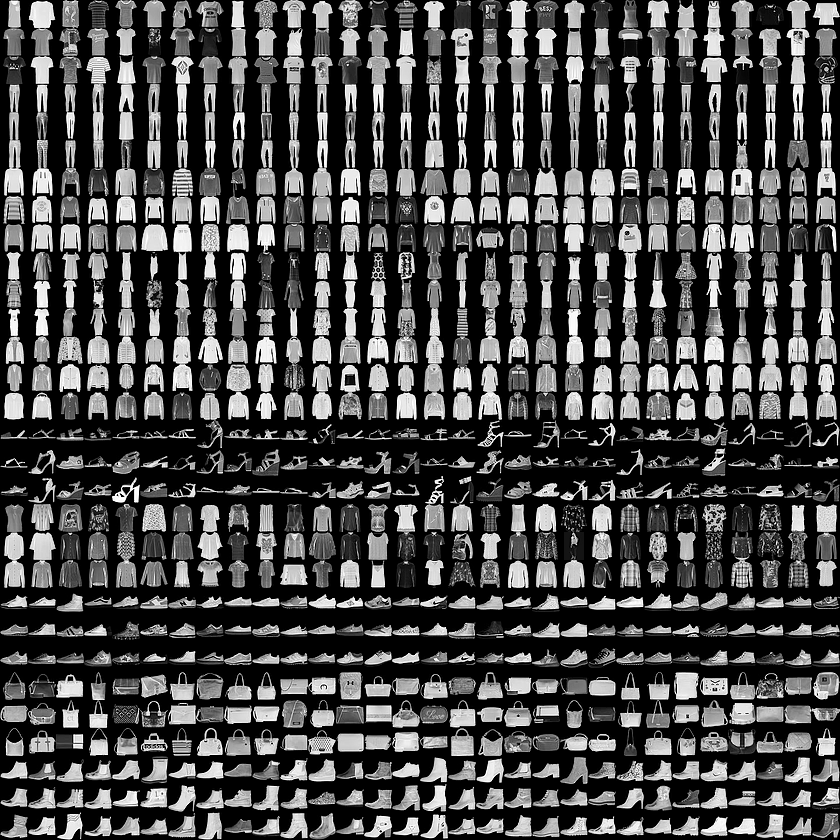

## **TAREFA**

Sigam as instruções acima cuidadosamente! A falta de justificativas detalhadas sobre a arquitetura escolhida, visualizações utilizadas e/ou falta de documentação adequada e completa invalidará esta parte da AC.

O grupo deverá fazer todas es etapas necessárias tanto na avaliação dos dados disponíveis quanto na preparação necessária para execução do modelo. Todas as etapas devem ser documentadas e as escolhas justificadas. Todos os componentes do grupo deverão ser capazes de justificar as escolhas técnicas durante a apresentação do trabalho.

A performance do modelo deverá ser avaliada através da aplicação correta das técnicas aprendidas e a métrica principal deverá ser a **acurácia**.

Os grupos apresentarão seus esforços a partir de uma apresentação de negócio (direta, bem feita, com uso amplo de visualizações de dados e focada nos resultados gerais), além do próprio Colab, que deverá estar organizado e documentado, incluindo as principais escolhas, critérios de cálculo, sempre que necessário, desafios encontrados e resultados.  

Imaginem o cenário onde vocês irão justificar a utilização do modelo proposto por vocês em uma reunião curta com o CTO (Chief Technology Officer) de uma grande empresa, em uma reunião rápida. Será a oportunidade que sua pequena empresa buscava há um bom tempo de mostrar que vale a pena o investimento em vocês!

A apresentação dos grupos será feita em sala, no dia 21/05/2025. Cada apresentação deverá durar no máximo 15 minutos e a entrega das apresentações e dos Colabs será feita no próprio dia da apresentação, por e-mail (cassius.figueiredo@professores.ibmec.edu.br). Não é necessário que todos os alunos do grupo falem na apresentação, um pode falar por todos, mas todos devem ser capazes de responder perguntas sobre o trabalho.

Este desafio comporá a última parte da AC, valendo até os 50% finais da nota final.

Não esqueçam de incluir toda e qualquer referência utilizada através da indicação numerada `[NÚMERO]`, e criar, ao final do Colab Notebook, uma célula com todas as referência organizadas. Referências fora do formato poderão acarretar desconto na nota final da avaliação.
```
EXEMPLO
"... segundo [10], a GANs podem ser utilizadas nos contextos ..."

Na célula de referências:
REFERÊNCIAS:
[1] ...
[2] ...
...
[10] Autor, Referência (Ano)
...
```

Referências de utilização de ferramentas de IA devem, obrigatoriamente, vir indicadas do nome da ferramenta utilizada, bem como o(s) prompt(s) utilizado(s), de forma organizada.



# 1 - EDA

**Primeiros iremos importar o conjunto de dados 'Fashion_mnist'**

In [ ]:
import tensorflow_datasets as tfds
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [ ]:
dataset = tfds.load(name="fashion_mnist")
fashion_mnist_train, fashion_mnist_test = dataset["train"], dataset["test"]

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/fashion_mnist/incomplete.JIWD09_3.0.1/fashion_mnist-train.tfrecord*...:   …

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/fashion_mnist/incomplete.JIWD09_3.0.1/fashion_mnist-test.tfrecord*...:   0…

Dataset fashion_mnist downloaded and prepared to /root/tensorflow_datasets/fashion_mnist/3.0.1. Subsequent calls will reuse this data.


**Os dados vem separados entre treino e teste, iremos juntar os dois em um só conjunto de dados para posteriormente separarmos em treino,teste e validação usando um embaralhamento personalizado melhor**

In [ ]:
full_dataset = fashion_mnist_train.concatenate(fashion_mnist_test)

In [ ]:
print(f"Element spec: {full_dataset.element_spec}")

Element spec: {'image': TensorSpec(shape=(28, 28, 1), dtype=tf.uint8, name=None), 'label': TensorSpec(shape=(), dtype=tf.int64, name=None)}


In [ ]:
total_images = full_dataset.cardinality().numpy()
print(f"Número de imagens: {total_images}")

Número de imagens: 70000


**Verificando as distribuições das classes no conjunto de dados**

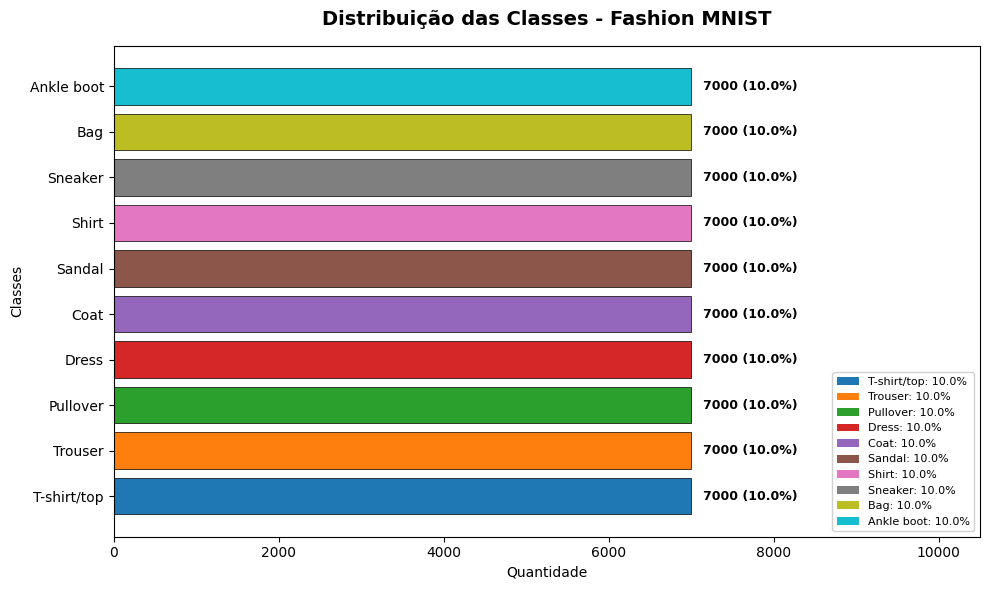

In [ ]:
from collections import Counter

# Extrair labels corretamente (TFDS)
labels = [int(item['label'].numpy()) for item in full_dataset]

# Contar ocorrências
counts = Counter(labels)

# Garantir classes 0–9
classes = list(range(10))
values = np.array([counts.get(c, 0) for c in classes])

# Percentuais
total = values.sum()
percentages = (values / total) * 100

# Nomes das classes
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

# Cores
colors = plt.cm.tab10.colors

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(class_names, values, color=colors,
               edgecolor='black', linewidth=0.5)

# Valores + percentuais
for bar, valor, percent in zip(bars, values, percentages):
    ax.text(valor + (total * 0.002),
            bar.get_y() + bar.get_height()/2,
            f'{int(valor)} ({percent:.1f}%)',
            va='center', ha='left',
            fontsize=9, fontweight='bold')

# Título
ax.set_title('Distribuição das Classes - Fashion MNIST',
             fontsize=14, fontweight='bold', pad=15)

ax.set_xlabel('Quantidade')
ax.set_ylabel('Classes')

# Legenda (igual ao seu estilo)
legend_elements = [
    plt.Rectangle((0, 0), 1, 1, facecolor=colors[i],
                  label=f'{class_names[i]}: {percentages[i]:.1f}%')
    for i in range(10)
]

ax.legend(handles=legend_elements, loc='lower right',
          fontsize=8, framealpha=0.9)

ax.set_xlim(0, max(values) + (total * 0.05))

plt.tight_layout()
plt.show()

**Podemos perceber que os dados estão balanceados, portanto futuramente quando estivermos olhando para métricas do modelo iremos olhar para a acurácia**

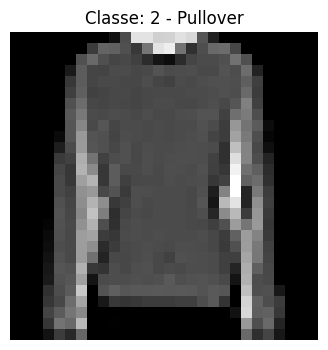

Shape da imagem: (28, 28, 1)


In [ ]:
classes = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

for example in full_dataset.take(1):
    imagem = example['image'].numpy()
    label = example['label'].numpy()
    plt.figure(figsize=(4, 4))
    plt.imshow(imagem, cmap="gray")
    plt.title(f"Classe: {label} - {classes[label]}")
    plt.axis('off')
    plt.show()
    print(f"Shape da imagem: {imagem.shape}")

**Dividimos o conjunto de dados seguindo a divisão: 70% treino, 15% validação e 15% para teste, além do mais embaralhamos o conjunto de dados antes da divisão, usando um buffer_size de 10.000, ou seja, embaralhando de 10 mil em 10 mil imagens, quanto maior o buffer_size melhor a aleatoriedade da divisão.**

In [ ]:
total_dataset_size = full_dataset.cardinality().numpy()
train_size = int(0.7 * total_dataset_size)
test_size = int(0.15 * total_dataset_size)
valid_size = int(0.15 * total_dataset_size)
print(f"Total: {total_dataset_size}")
print(f"Treino: {train_size}, Validação: {valid_size}, Teste: {test_size}")

data = full_dataset.shuffle(10_000, seed=42)
train_set = data.take(train_size)
remaining = data.skip(train_size)
val_set = remaining.take(valid_size)
test_set = remaining.skip(valid_size)

print(f"\nTamanhos após divisão:")
print(f"Treino: {tf.data.experimental.cardinality(train_set).numpy()}")
print(f"Validação: {tf.data.experimental.cardinality(val_set).numpy()}")
print(f"Teste: {tf.data.experimental.cardinality(test_set).numpy()}")

Total: 70000
Treino: 49000, Validação: 10500, Teste: 10500

Tamanhos após divisão:
Treino: 49000
Validação: 10500
Teste: 10500


**A seguir iremos verificar se a divisão preservou a distribuição original das classes, é claro que não precisa ser o mesmo percentual, visto que é alatório porém deve-se preservar mais ou menos o que é o conjunto de dados original**

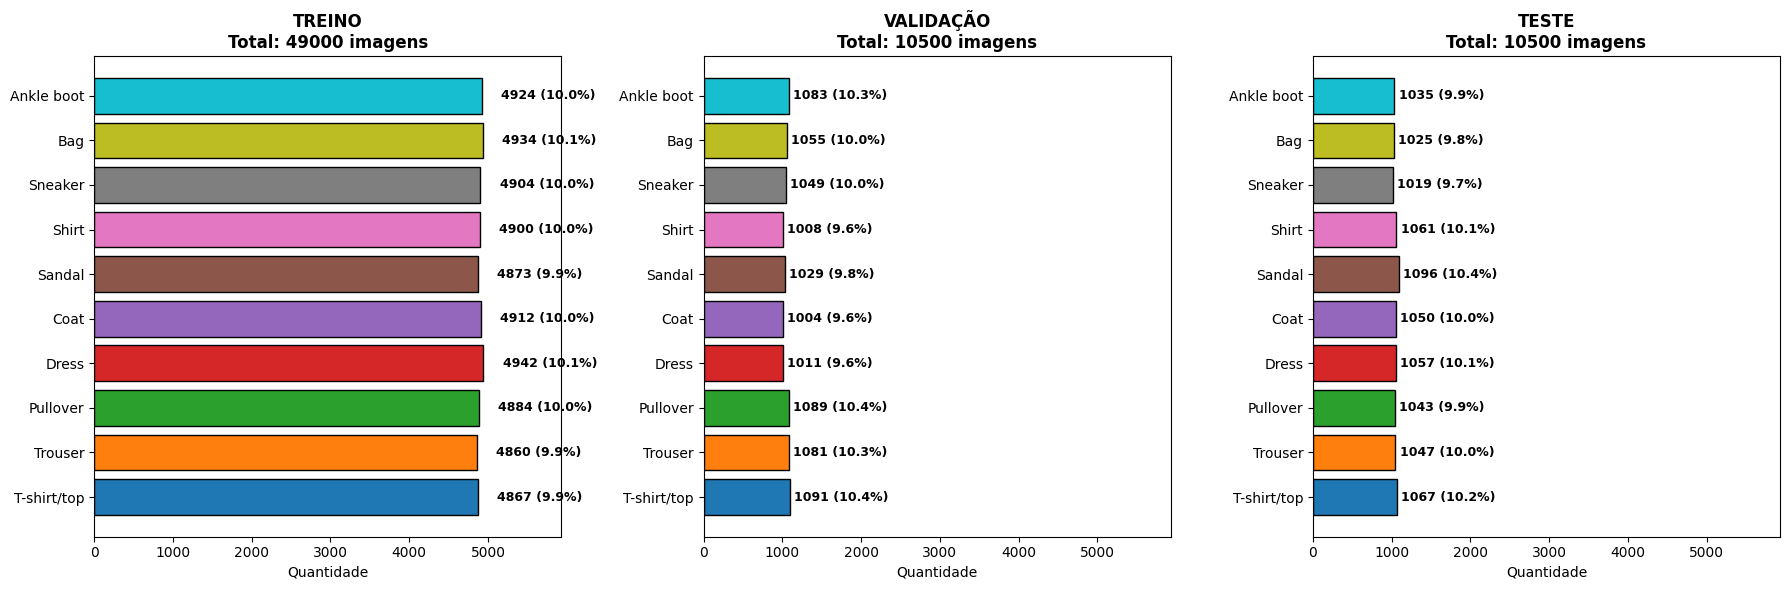

In [ ]:
# Função adaptada para dicionário
def contar_labels_fashion(dataset):
    labels = []
    for exemplo in dataset:
        labels.append(int(exemplo['label'].numpy()))
    return Counter(labels)


# Contar em cada conjunto
train_counts = contar_labels_fashion(train_set)
val_counts = contar_labels_fashion(val_set)
test_counts = contar_labels_fashion(test_set)

classes = list(range(10))

train_values = np.array([train_counts.get(c, 0) for c in classes])
val_values = np.array([val_counts.get(c, 0) for c in classes])
test_values = np.array([test_counts.get(c, 0) for c in classes])

# Percentuais
train_pct = (train_values / train_values.sum()) * 100
val_pct = (val_values / val_values.sum()) * 100
test_pct = (test_values / test_values.sum()) * 100

# Nomes das classes
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

colors = plt.cm.tab10.colors


fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# ===== TREINO =====
bars1 = axes[0].barh(class_names, train_values,
                     color=colors, edgecolor='black')

axes[0].set_title(f'TREINO\nTotal: {train_values.sum()} imagens',
                  fontweight='bold')

for i, (valor, pct) in enumerate(zip(train_values, train_pct)):
    axes[0].text(valor + (train_values.sum() * 0.005), i,
                 f'{valor} ({pct:.1f}%)',
                 va='center', ha='left', fontsize=9, fontweight='bold')

# ===== VALIDAÇÃO =====
bars2 = axes[1].barh(class_names, val_values,
                     color=colors, edgecolor='black')

axes[1].set_title(f'VALIDAÇÃO\nTotal: {val_values.sum()} imagens',
                  fontweight='bold')

for i, (valor, pct) in enumerate(zip(val_values, val_pct)):
    axes[1].text(valor + (val_values.sum() * 0.005), i,
                 f'{valor} ({pct:.1f}%)',
                 va='center', ha='left', fontsize=9, fontweight='bold')

# ===== TESTE =====
bars3 = axes[2].barh(class_names, test_values,
                     color=colors, edgecolor='black')

axes[2].set_title(f'TESTE\nTotal: {test_values.sum()} imagens',
                  fontweight='bold')

for i, (valor, pct) in enumerate(zip(test_values, test_pct)):
    axes[2].text(valor + (test_values.sum() * 0.005), i,
                 f'{valor} ({pct:.1f}%)',
                 va='center', ha='left', fontsize=9, fontweight='bold')

# Ajustes finais
for ax in axes:
    ax.set_xlabel('Quantidade')
    ax.set_xlim(0, max(train_values.max(), val_values.max(), test_values.max()) * 1.2)

plt.tight_layout()
plt.show()

**Agora que temos os dados já divididos e preservando a distribuição original das duas classes nos 3 subconjuntos iremos olhar melhor as dimensões das imagens de treino, para encontrar as imagens de maior e menor dimensão, para posteriormente nos modelos definirmos qual o tamanho para as imagens de entrada**


📊 ESTATÍSTICAS DAS DIMENSÕES
Total de imagens analisadas: 49000

📏 ALTURA:
   Mediana: 28.0 pixels
   Mínimo: 28 pixels
   Máximo: 28 pixels
   Desvio padrão: 0.0

📐 LARGURA:
   Mediana: 28.0 pixels
   Mínimo: 28 pixels
   Máximo: 28 pixels
   Desvio padrão: 0.0

📊 PROPORÇÃO (Altura/Largura):
   Mediana: 1.00


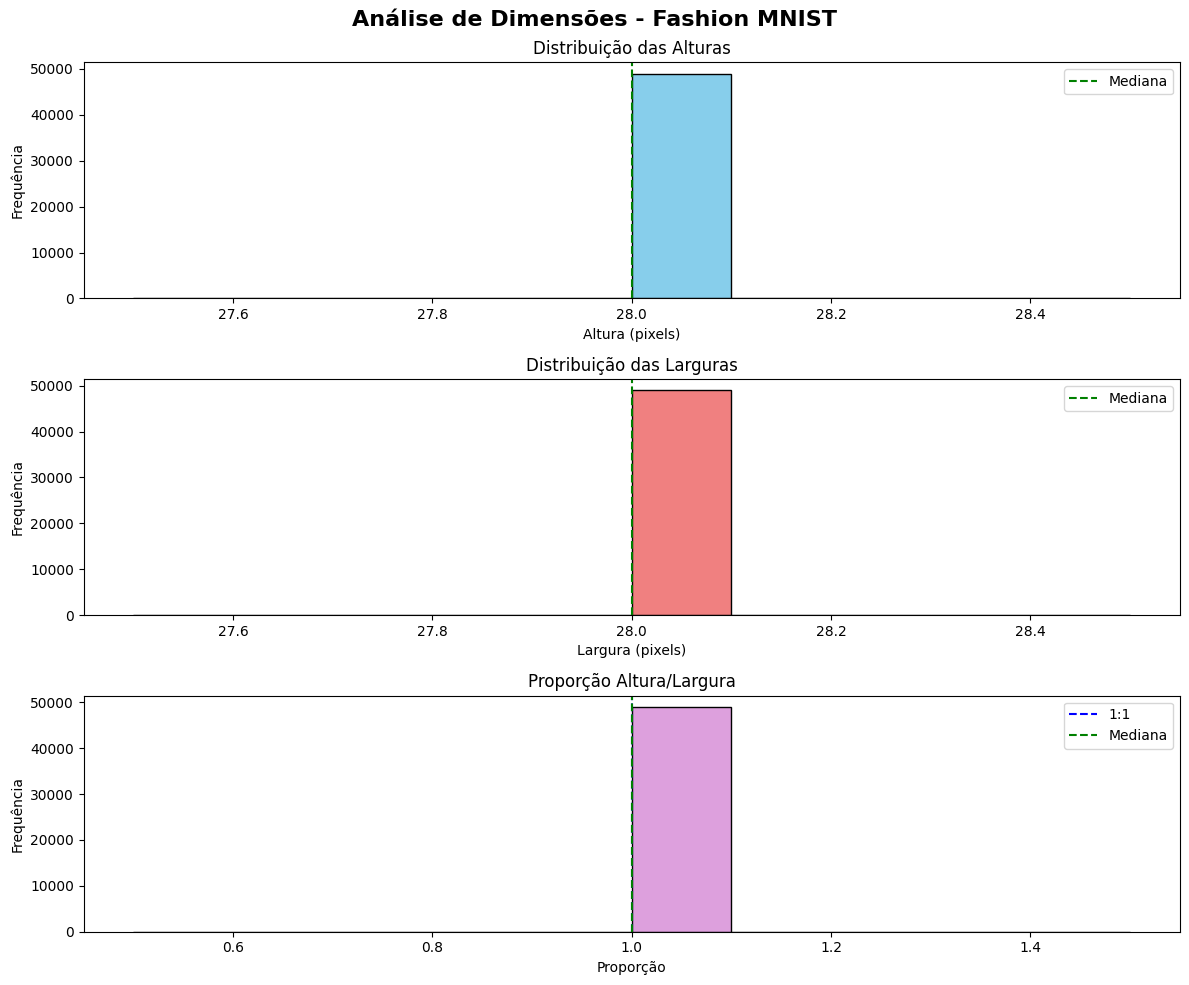

In [ ]:
def coletar_dimensoes(dataset, max_amostras=None):
    alturas = []
    larguras = []
    proporcoes = []

    count = 0
    for exemplo in dataset:
        imagem = exemplo['image'].numpy()

        h, w = imagem.shape[0], imagem.shape[1]

        alturas.append(h)
        larguras.append(w)
        proporcoes.append(h / w)

        count += 1
        if max_amostras and count >= max_amostras:
            break

    return {
        'alturas': np.array(alturas),
        'larguras': np.array(larguras),
        'proporcoes': np.array(proporcoes)
    }
dimensoes = coletar_dimensoes(train_set)

print("\n" + "="*60)
print("📊 ESTATÍSTICAS DAS DIMENSÕES")
print("="*60)

print(f"Total de imagens analisadas: {len(dimensoes['alturas'])}")

print(f"\n📏 ALTURA:")
print(f"   Mediana: {np.median(dimensoes['alturas']):.1f} pixels")
print(f"   Mínimo: {np.min(dimensoes['alturas'])} pixels")
print(f"   Máximo: {np.max(dimensoes['alturas'])} pixels")
print(f"   Desvio padrão: {np.std(dimensoes['alturas']):.1f}")

print(f"\n📐 LARGURA:")
print(f"   Mediana: {np.median(dimensoes['larguras']):.1f} pixels")
print(f"   Mínimo: {np.min(dimensoes['larguras'])} pixels")
print(f"   Máximo: {np.max(dimensoes['larguras'])} pixels")
print(f"   Desvio padrão: {np.std(dimensoes['larguras']):.1f}")

print(f"\n📊 PROPORÇÃO (Altura/Largura):")
print(f"   Mediana: {np.median(dimensoes['proporcoes']):.2f}")
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

fig.suptitle(
    'Análise de Dimensões - Fashion MNIST',
    fontsize=16,
    fontweight='bold'
)

# ALTURA
axes[0].hist(dimensoes['alturas'], bins=10,
             color='skyblue', edgecolor='black')

axes[0].axvline(np.median(dimensoes['alturas']),
                color='green', linestyle='--',
                label='Mediana')

axes[0].set_title('Distribuição das Alturas')
axes[0].set_xlabel('Altura (pixels)')
axes[0].set_ylabel('Frequência')
axes[0].legend()

# LARGURA
axes[1].hist(dimensoes['larguras'], bins=10,
             color='lightcoral', edgecolor='black')

axes[1].axvline(np.median(dimensoes['larguras']),
                color='green', linestyle='--',
                label='Mediana')

axes[1].set_title('Distribuição das Larguras')
axes[1].set_xlabel('Largura (pixels)')
axes[1].set_ylabel('Frequência')
axes[1].legend()

# PROPORÇÃO
axes[2].hist(dimensoes['proporcoes'], bins=10,
             color='plum', edgecolor='black')

axes[2].axvline(1.0, color='blue', linestyle='--', label='1:1')
axes[2].axvline(np.median(dimensoes['proporcoes']),
                color='green', linestyle='--',
                label='Mediana')

axes[2].set_title('Proporção Altura/Largura')
axes[2].set_xlabel('Proporção')
axes[2].set_ylabel('Frequência')
axes[2].legend()

plt.tight_layout()
plt.show()

**como podemos ver todas as imagens possuem o mesmo tamanho: 28x28 em grayscale ou seja apenas 1 canal**

# 2 - Pré-processamento

**Agora iremos pré-processar as imagens para a entrada nos modelos: lembrando que não é necessário realizar o redimensionamento de nenhuma imagem, pois neste problema todas as imagens já vem com o mesmo tamanho, portanto fazemos apenas a normalização dos pixels de 0 - 255 para 0 - 1, além da conversão em float32**

In [ ]:
# Função para extrair imagem, label E normalizar
def preprocess_image(batch):
    image = batch['image']
    label = batch['label']
    # Converter para float32 e normalizar para [0,1]
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

In [ ]:
# Aplicar o pré-processamento
train_set = train_set.map(preprocess_image)
val_set = val_set.map(preprocess_image)
test_set = test_set.map(preprocess_image)

**Iremos configurar os datasets em batchs: primeiro embaralhamos novamente os dados de treino, organizamos os dados em batchs de tamanho 128 e usamos a pré-busca que carrega o próximo batch enquanto treino o atual, melhorando o desempenho da GPU[1]**

In [ ]:
train_set = train_set.shuffle(5_000, seed=42).batch(128).prefetch(tf.data.AUTOTUNE)
valid_set = val_set.batch(128).cache().prefetch(tf.data.AUTOTUNE)
test_set = test_set.batch(128).cache().prefetch(tf.data.AUTOTUNE)

# 3 - Modelos

## LENET

**como forma de Benchmark implementamos a LENET-5, consideramos esse modelo um bom benchmark pois é um modelo simples, de fácil entendimento e rápido tanto de treinar quanto de inferência devido a sua profundidade não ser grande. Na sequência iremos buscar um modelo que supera a acurácia da LENET-5**

In [ ]:
from tensorflow import keras
from keras.layers import MaxPooling2D, Dense, Conv2D, Flatten
from keras.models import Sequential
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

**Devido a quantidade de vezes que ao rodarmos percebemos um overfitting e ao número relativamente alto de epochs(30), implementamos um Earlystopping personalizado que trabalha em cima das diferenças das acurácias de validação e treinamento durante o treinamento, previnindo que eles se distanciam em mais de 3%, esperando até 3 epochs para esse "gap" diminuir, caso não diminua o treinamento é interrompido naquela epoch**

In [ ]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

class F1GapEarlyStopping(tf.keras.callbacks.Callback):
    def __init__(self, threshold=0.1, patience=3):
        super().__init__()
        self.threshold = threshold
        self.patience = patience
        self.wait = 0

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}

        train_accuracy = logs.get("accuracy")
        val_accuracy = logs.get("val_accuracy")

        if train_accuracy is None or val_accuracy is None:
            return

        gap = abs(train_accuracy - val_accuracy)

        print(f"📊 Gap Accuracy: {gap:.4f}")

        if gap > self.threshold:
            self.wait += 1
            print(f"⚠️ Gap alto ({self.wait}/{self.patience})")

            if self.wait >= self.patience:
                print("🛑 Early stopping: overfitting detectado (gap alto)")
                self.model.stop_training = True
        else:
            self.wait = 0

early_stopping = F1GapEarlyStopping(
    threshold=0.03,
    patience=3
)

In [ ]:
batch_size=128
num_classes=10
epochs=30

def build_model(optimizer):
    model=Sequential()
    model.add(Conv2D(filters=32, kernel_size=(5,5), padding='same', activation='tanh', input_shape=(28, 28, 1)))
    model.add(MaxPooling2D(strides=2))
    model.add(Conv2D(filters=48, kernel_size=(5,5), padding='valid', activation='tanh'))
    model.add(MaxPooling2D(strides=2))
    model.add(Flatten())
    model.add(Dense(120, activation='tanh'))
    model.add(Dense(84, activation='tanh'))
    model.add(Dense(10, activation="softmax"))


    model.compile(loss="sparse_categorical_crossentropy",optimizer= optimizer, metrics=['accuracy'])
    return model

In [ ]:
lenet_model = build_model('Adam')

history_lenet = lenet_model.fit(train_set, validation_data=valid_set, batch_size=batch_size,
                 epochs=epochs, callbacks=[early_stopping], verbose=1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7552 - loss: 0.6917📊 Gap Accuracy: 0.0510
⚠️ Gap alto (1/3)
383/383 ━━━━━━━━━━━━━━━━━━━━ 12s 20ms/step - accuracy: 0.8231 - loss: 0.4934 - val_accuracy: 0.8742 - val_loss: 0.3501
Epoch 2/30
373/383 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8774 - loss: 0.3418📊 Gap Accuracy: 0.0135
383/383 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8823 - loss: 0.3220 - val_accuracy: 0.8958 - val_loss: 0.2974
Epoch 3/30
381/383 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8973 - loss: 0.2806📊 Gap Accuracy: 0.0072
383/383 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8988 - loss: 0.2768 - val_accuracy: 0.9060 - val_loss: 0.2605
Epoch 4/30
374/383 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9068 - loss: 0.2530 📊 Gap Accuracy: 0.0040
383/383 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9078 - loss: 0.2493 - val_accuracy: 0.9038 - val_loss: 0.2616
Epoch 5/30
380/383 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9149 - loss

In [ ]:
lenet_model.evaluate(test_set)

83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9252 - loss: 0.2516


[0.2516348659992218, 0.9252380728721619]

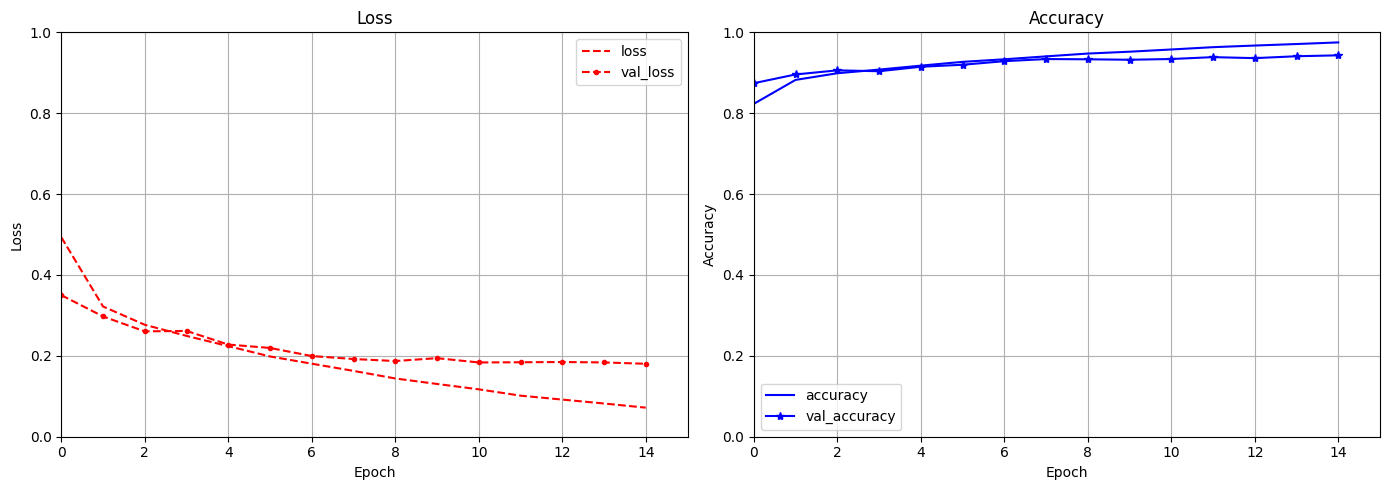

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Loss x Epoch
pd.DataFrame(history_lenet.history)[["loss", "val_loss"]].plot(
    ax=axes[0],
    xlim=[0, 15],
    ylim=[0, 1],
    grid=True,
    xlabel="Epoch",
    style=["r--", "r--."],
    title="Loss"
)
axes[0].set_ylabel("Loss")

# Gráfico 2: Accuracy x Epoch
pd.DataFrame(history_lenet.history)[["accuracy", "val_accuracy"]].plot(
    ax=axes[1],
    xlim=[0, 15],
    ylim=[0, 1],
    grid=True,
    xlabel="Epoch",
    style=["b-", "b-*"],
    title="Accuracy"
)
axes[1].set_ylabel("Accuracy")

plt.tight_layout()
plt.show()

## RESNET34 adaptada

**Depois de várias tentativas de diversos modeos que visam superar a LENET-5, optamos pela RESNET34, é importante dizer que não testamos muitos modelos maiores devido a suas altas demandas computacionais(consumo de credito do collab, tempo de treinamento, quantidade de parâmetros) até mesmo por exemplo versões mais complexas da RESNET, como a RESNET50, RESNET152, etc.**

**Sobre a RESNET34: uma rede extremamente profunda que introduziu o conceito de "SKIP CONNECTIONS", onde a saída de uma camada é somada diretamente á saída de camadas mais á frente.Essas conexões são usadas nos "BLOCOS RESIDUAIS" que deixou muito mais fácil treinar redes extremamente profunda. Usamos a variante com 34 camadas(contando as convolucionais, totalmente conectadas e as de pooling), o que torna nossa RESNET muito mais profunda que a LENET que possui 7.**

**Cada bloco residual é formado por 2 camadas convolucionais, 2 camadas de normalização(batch normalization) e ativação RELU**

**o código a seguir foi inspirado em [1] e em [2], a única adaptação necessária foi na primeira camada de pooling e na primeira camada de convolução do modelo, ainda antes das unidades residuais, o kernel size foi trocado de 7 para 3 e o stride de 2 para 1, visando manter as dimensões da imagens nessas primeiras camadas, visto que a RESNET34 foi pensada para ser usada em imagens 224x224x3 e nossas imagens têm 28x28x1. Além disso, o input_shape foi obviamente mudado.**

In [ ]:
from functools import partial
DefaultConv2D = partial(tf.keras.layers.Conv2D, kernel_size=3, strides=1,
                        padding="same", kernel_initializer="he_normal",
                        use_bias=False)

class ResidualUnit(tf.keras.layers.Layer):
    def __init__(self, filters, strides=1, activation="relu", **kwargs):
        super().__init__(**kwargs)
        self.activation = tf.keras.activations.get(activation)
        self.main_layers = [
            DefaultConv2D(filters, strides=strides),
            tf.keras.layers.BatchNormalization(),
            self.activation,
            DefaultConv2D(filters),
            tf.keras.layers.BatchNormalization()
        ]
        self.skip_layers = []
        if strides > 1:
            self.skip_layers = [
                DefaultConv2D(filters, kernel_size=1, strides=strides),
                tf.keras.layers.BatchNormalization()
            ]

    def call(self, inputs):
        Z = inputs
        for layer in self.main_layers:
            Z = layer(Z)
        skip_Z = inputs
        for layer in self.skip_layers:
            skip_Z = layer(skip_Z)
        return self.activation(Z + skip_Z)

In [ ]:
resnet34_model = tf.keras.Sequential([
    DefaultConv2D(64, kernel_size=3, strides=1, input_shape=[28, 28, 1]),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    tf.keras.layers.MaxPool2D(pool_size=3, strides=1, padding="same"),
])
prev_filters = 64
for filters in [64] * 3 + [128] * 4 + [256] * 6 + [512] * 3:
    strides = 1 if filters == prev_filters else 2
    resnet34_model.add(ResidualUnit(filters, strides=strides))
    prev_filters = filters

resnet34_model.add(tf.keras.layers.GlobalAvgPool2D())
resnet34_model.add(tf.keras.layers.Flatten())
resnet34_model.add(tf.keras.layers.Dense(10, activation="softmax"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
resnet34_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 64)     │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit (ResidualUnit)    │ (None, 28, 28, 64)     │        74,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_1 (ResidualUnit)  │ (None, 28, 28, 64)     │        74,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_2 (ResidualUnit)  │ (None, 28, 28, 64)     │        74,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_3 (ResidualUnit)  │ (None, 14, 14, 128)    │       230,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_4 (ResidualUnit)  │ (None, 14, 14, 128)    │       295,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_5 (ResidualUnit)  │ (None, 14, 14, 128)    │       295,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_6 (ResidualUnit)  │ (None, 14, 14, 128)    │       295,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_7 (ResidualUnit)  │ (None, 7, 7, 256)      │       920,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_8 (ResidualUnit)  │ (None, 7, 7, 256)      │     1,181,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_9 (ResidualUnit)  │ (None, 7, 7, 256)      │     1,181,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_10 (ResidualUnit) │ (None, 7, 7, 256)      │     1,181,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_11 (ResidualUnit) │ (None, 7, 7, 256)      │     1,181,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_12 (ResidualUnit) │ (None, 7, 7, 256)      │     1,181,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_13 (ResidualUnit) │ (None, 4, 4, 512)      │     3,676,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_14 (ResidualUnit) │ (None, 4, 4, 512)      │     4,722,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_15 (ResidualUnit) │ (None, 4, 4, 512)      │     4,722,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 63,859,936 (243.61 MB)

 Trainable params: 21,280,970 (81.18 MB)

 Non-trainable params: 17,024 (66.50 KB)

 Optimizer params: 42,561,942 (162.36 MB)

In [ ]:
optimizer = tf.keras.optimizers.Adam()
resnet34_model.compile(loss="sparse_categorical_crossentropy",optimizer= optimizer, metrics=['accuracy'])

In [ ]:
history_resnet34 = resnet34_model.fit(train_set, validation_data=valid_set, batch_size=batch_size,
                 epochs=epochs, callbacks=[early_stopping], verbose=1)

Epoch 1/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step - accuracy: 0.7774 - loss: 0.7158📊 Gap Accuracy: 0.0296
383/383 ━━━━━━━━━━━━━━━━━━━━ 133s 248ms/step - accuracy: 0.8536 - loss: 0.4304 - val_accuracy: 0.8832 - val_loss: 0.3383
Epoch 2/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step - accuracy: 0.8988 - loss: 0.2777📊 Gap Accuracy: 0.0167
383/383 ━━━━━━━━━━━━━━━━━━━━ 81s 210ms/step - accuracy: 0.9049 - loss: 0.2625 - val_accuracy: 0.8882 - val_loss: 0.2950
Epoch 3/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step - accuracy: 0.9172 - loss: 0.2269📊 Gap Accuracy: 0.0151
383/383 ━━━━━━━━━━━━━━━━━━━━ 81s 210ms/step - accuracy: 0.9177 - loss: 0.2244 - val_accuracy: 0.9026 - val_loss: 0.2584
Epoch 4/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step - accuracy: 0.9283 - loss: 0.1952📊 Gap Accuracy: 0.0008
383/383 ━━━━━━━━━━━━━━━━━━━━ 80s 210ms/step - accuracy: 0.9286 - loss: 0.1951 - val_accuracy: 0.9277 - val_loss: 0.1937
Epoch 5/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step - accuracy: 0.9363 - loss

In [ ]:
resnet34_model.evaluate(test_set)

83/83 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - accuracy: 0.9339 - loss: 0.2535


[0.2534947097301483, 0.933904767036438]

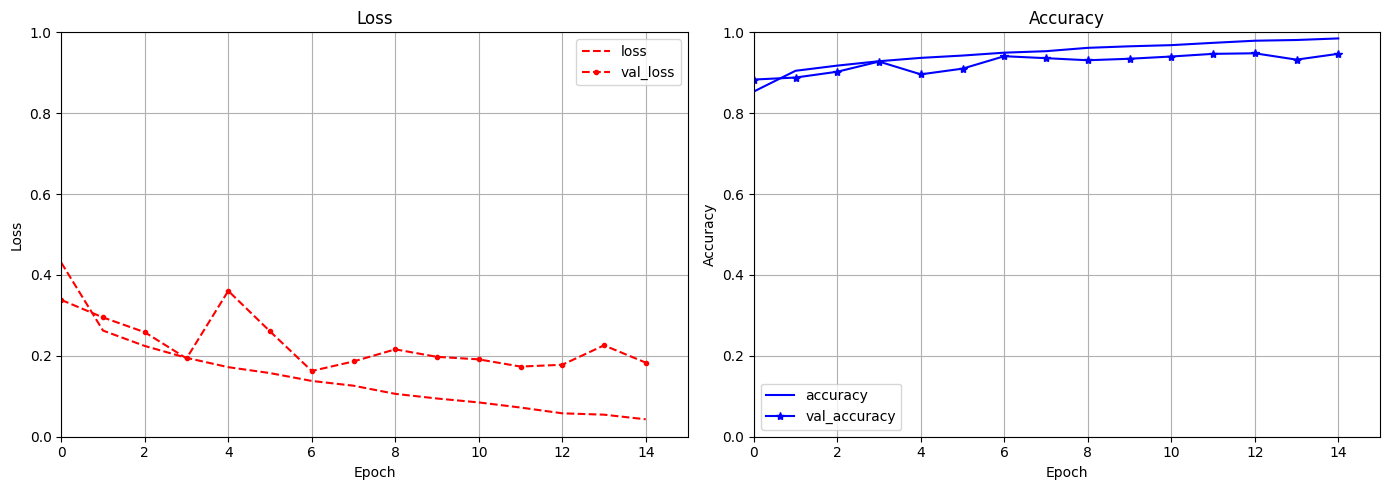

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Loss x Epoch
pd.DataFrame(history_resnet34.history)[["loss", "val_loss"]].plot(
    ax=axes[0],
    xlim=[0, 15],
    ylim=[0, 1],
    grid=True,
    xlabel="Epoch",
    style=["r--", "r--."],
    title="Loss"
)
axes[0].set_ylabel("Loss")

# Gráfico 2: Accuracy x Epoch
pd.DataFrame(history_resnet34.history)[["accuracy", "val_accuracy"]].plot(
    ax=axes[1],
    xlim=[0, 15],
    ylim=[0, 1],
    grid=True,
    xlabel="Epoch",
    style=["b-", "b-*"],
    title="Accuracy"
)
axes[1].set_ylabel("Accuracy")

plt.tight_layout()
plt.show()

# 4 - Referências

[1] - Géron, Aurélien. Hands-on machine learning with Scikit-Learn, Keras,
and TensorFlow. " O'Reilly Media, Inc.", 2022.


---


[2] - He, Kaiming, et al. "Deep residual learning for image recognition." Proceedings of the IEEE conference on computer vision and pattern recognition. 2016.